In [1]:
import os
os.environ.pop("MPLBACKEND", None)

%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import os
os.environ.pop("CUDA_VISIBLE_DEVICES", None)
# or force it:
# os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("cuda available:", torch.cuda.is_available())
print("device count:", torch.cuda.device_count())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No CUDA")

CUDA_VISIBLE_DEVICES: None
cuda available: True
device count: 1
NVIDIA GeForce RTX 3070 Laptop GPU


In [3]:
import os
SEED = 67


import gc
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
from datetime import datetime
from scipy import signal

print("torch:", torch.__version__)
print("cuda build:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
print("cuda device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("cuda device name:", torch.cuda.get_device_name(0))
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


torch.manual_seed(SEED)

torch: 2.12.0+cu126
cuda build: 12.6
cuda available: True
cuda device count: 1
cuda device name: NVIDIA GeForce RTX 3070 Laptop GPU


In [4]:
from data_processing.multimodal_radar_dataset import radar_dataset_multimodal

In [5]:
import importlib
from pathlib import Path
import data_processing.multimodal_radar_dataset as multimodal_dataset_module

importlib.reload(multimodal_dataset_module)
radar_dataset_multimodal = multimodal_dataset_module.radar_dataset_multimodal

# list_length includes the target frame, so 6 gives 5 input timesteps.
sample_size = 6
land_use_path = Path(r"C:\Users\Jacobs laptop\rainraingoaway\data\land_use_masks.npy")
dataset = radar_dataset_multimodal(
    r"C:\Users\Jacobs laptop\rainraingoaway\data\70km\png",
    r"C:\Users\Jacobs laptop\rainraingoaway\data\environment",
    list_length=sample_size,
    total=None,
    num_workers=14,
    land_use_path=str(land_use_path),
)
split_idx = int(0.8 * len(dataset))

train_dataset = torch.utils.data.Subset(dataset, range(0, split_idx))
test_dataset = torch.utils.data.Subset(dataset, range(split_idx, len(dataset)))

loaded 202605191430.png from cache with shape (7, 120, 217)
loaded 202605191435.png from cache with shape (7, 120, 217)
loaded 202605191440.png from cache with shape (7, 120, 217)
loaded 202605191445.png from cache with shape (7, 120, 217)
loaded 202605191450.png from cache with shape (7, 120, 217)
loaded 202605191455.png from cache with shape (7, 120, 217)
loaded 202605191500.png from cache with shape (7, 120, 217)
loaded 202605191510.png from cache with shape (7, 120, 217)
loaded 202605191505.png from cache with shape (7, 120, 217)
loaded 202605191520.png from cache with shape (7, 120, 217)
loaded 202605191530.png from cache with shape (7, 120, 217)
loaded 202605191525.png from cache with shape (7, 120, 217)
loaded 202605191515.png from cache with shape (7, 120, 217)
loaded 202605191535.png from cache with shape (7, 120, 217)
loaded 202605191540.png from cache with shape (7, 120, 217)
loaded 202605191555.png from cache with shape (7, 120, 217)
loaded 202605191545.png from cache with 

In [6]:
from torch.utils.data import DataLoader
BATCH_SIZE = 16 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Train batches :{len(train_loader)}")
print(f"Test batches :{len(test_loader)}")

Train samples: 2079
Test samples: 520
Train batches :130
Test batches :33


In [7]:
for inputs, labels in train_loader:
    print("inputs shape:", inputs.shape)
    print("labels shape:", labels.shape)
    assert inputs.shape[2] == 40, f"Expected 40 channels, got {inputs.shape[2]}"
    break

inputs shape: torch.Size([16, 5, 40, 120, 217])
labels shape: torch.Size([16, 120, 217])


In [8]:
import importlib
import models.multi_modal_convlstm as multimodal_model_module

importlib.reload(multimodal_model_module)
ConvLSTM_MM = multimodal_model_module.ConvLSTM_MM

model = ConvLSTM_MM(input_dim=7,
                   hidden_dim=[32, 64],
                   kernel_size=[(3, 3), (3, 3)],
                   num_layers=2,
                   batch_first=True,
                   bias=True,
                   land_use_channels=33,
                   land_use_feature_dim=8)

model = model.to(device)

In [9]:
import torch.optim
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [10]:
#define loss functions

pos_weight = 30.0
neg_weight = 1.0
bce_logits_loss = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor([30.0]).to(device))

def weighted_regression_loss(predictions, targets):
    weights = torch.where(targets > 0, pos_weight, neg_weight)
    return ((predictions - targets) ** 2 * weights).mean()


def weighted_smooth_l1_loss(pred, target, pos_weight=30.0, neg_weight=1.0, threshold=0.05):
    rain_mask = target > threshold
    weights = torch.where(
        rain_mask,
        torch.tensor(pos_weight, device=target.device),
        torch.tensor(neg_weight, device=target.device)
    )
    weights = weights / weights.mean()

    loss = F.smooth_l1_loss(pred, target, reduction='none')
    return (loss * weights).mean()

def radar_intensity_loss(
    pred,
    target,
    rain_threshold=0.01,
    background_weight=0.2,
    rain_weight=3,
    intensity_weight=2.0,
    beta=0.05
):
    loss = F.smooth_l1_loss(
        pred,
        target,
        reduction="none",
        beta=beta
    )

    rain_mask = (target > rain_threshold).float()

    weights = background_weight + rain_mask * rain_weight + target * intensity_weight

    return (loss * weights).sum() / weights.sum().clamp_min(1.0)



In [11]:
loss_fn = radar_intensity_loss

In [12]:
def train_one_epoch(epoch_index, optimizer, model, loss_fn):
    running_loss = 0 
    last_loss = 0 
    for i , data in enumerate(train_loader):
        inputs, labels= data 
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        layer_output_list = model(inputs)

        outputs = layer_output_list
        
        #if labels.dim() == 3:
         #   labels = labels.unsqueeze(1)  # [batch, 120, 217] -> [batch, 1, 120, 217]
        
        #print(f"label: {labels.shape}")
        #print(f"output: {outputs.shape}")
        outputs= outputs.squeeze(1)
        #print(outputs.shape)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        if i % 10 == 9:
            last_loss = running_loss / 10 # loss per batch
            print(f'  batch {i + 1} loss: {last_loss}')
            tb_x = epoch_index * len(train_loader) + i + 1
           
            running_loss = 0.
    return last_loss  

In [ ]:


epoch_number = 0
val=[]
train=[]
EPOCHS = 400
EARLY_STOPPING_PATIENCE = 50

best_vloss = float("inf")
epochs_without_improvement = 0
model_path = "model_best.pkl"

for epoch in range(EPOCHS):
    print(f'EPOCH {epoch_number + 1}:')

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_train_loss = train_one_epoch(epoch_number, optimizer,model,loss_fn)

    running_vloss = 0.0
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(test_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            layer_output_list = model(vinputs)

            voutputs = layer_output_list.squeeze(1)
            vloss = loss_fn(voutputs, vlabels.float())
            running_vloss += vloss.item()

    avg_val_loss = running_vloss / max(len(test_loader), 1)
    print(f'LOSS train {avg_train_loss} valid {avg_val_loss}')
    val.append(avg_val_loss)
    train.append(avg_train_loss)

    # Track best performance, and save the model's state
    if avg_val_loss < best_vloss:
        best_vloss = avg_val_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(
            f"Early stopping triggered after {epoch_number + 1} epochs "
            f"with no validation improvement for {EARLY_STOPPING_PATIENCE} epochs."
        )
        break

    epoch_number += 1

model.load_state_dict(torch.load(model_path, map_location=device))
print("Restored best model weights from model_best.pkl")

EPOCH 1:
  batch 10 loss: 0.15803705975413324
  batch 20 loss: 0.043992400355637076
  batch 30 loss: 0.038334315083920954
  batch 40 loss: 0.029209068976342678
  batch 50 loss: 0.03455395083874464
  batch 60 loss: 0.04563635904341936
  batch 70 loss: 0.03374852184206247
  batch 80 loss: 0.034037664905190466
  batch 90 loss: 0.029029443673789502
  batch 100 loss: 0.03666413193568587
  batch 110 loss: 0.024960825499147177
  batch 120 loss: 0.03402826227247715
  batch 130 loss: 0.027547950483858587
LOSS train 0.027547950483858587 valid 0.02151051460003311
EPOCH 2:
  batch 10 loss: 0.031303792633116244
  batch 20 loss: 0.029569941200315954
  batch 30 loss: 0.026608181186020374
  batch 40 loss: 0.03718574168160558
  batch 50 loss: 0.03782151071354747
  batch 60 loss: 0.026867086160928012
  batch 70 loss: 0.0312046704813838
  batch 80 loss: 0.030328594613820314
  batch 90 loss: 0.039071733504533766
  batch 100 loss: 0.03330339035019279
  batch 110 loss: 0.02665612204000354
  batch 120 loss: 

In [ ]:
model2 = ConvLSTM_MM(input_dim=7,
                    hidden_dim=[32, 64],
                    kernel_size=[(3, 3), (3, 3)],
                    num_layers=2,
                    batch_first=True,
                    bias=True,
                    land_use_channels=33,
                    land_use_feature_dim=8)

model2 = model2.to(device)
model2.load_state_dict(torch.load(r"C:\Users\Jacobs laptop\rainraingoaway\src\model_best.pkl", map_location=device))
print("Loaded model_best.pkl into model2")

Loaded model_best.pkl into model2


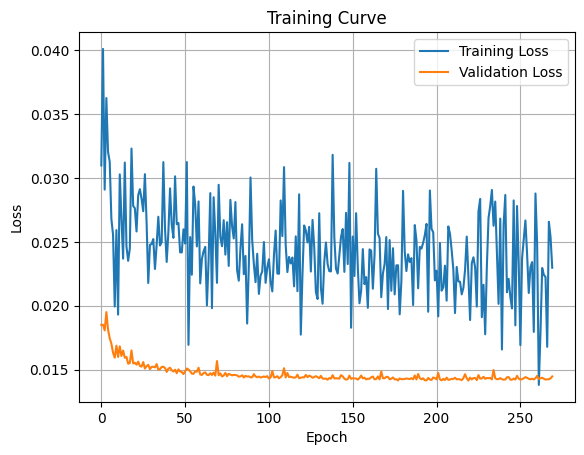

In [ ]:
plt.plot(train, label="Training Loss")
plt.plot(val, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.legend()
plt.grid(True)
plt.show()

Prediction range: -0.0176 to 0.1549
Actual range: 0.0000 to 0.4400
Difference range: -0.4327 to 0.1549


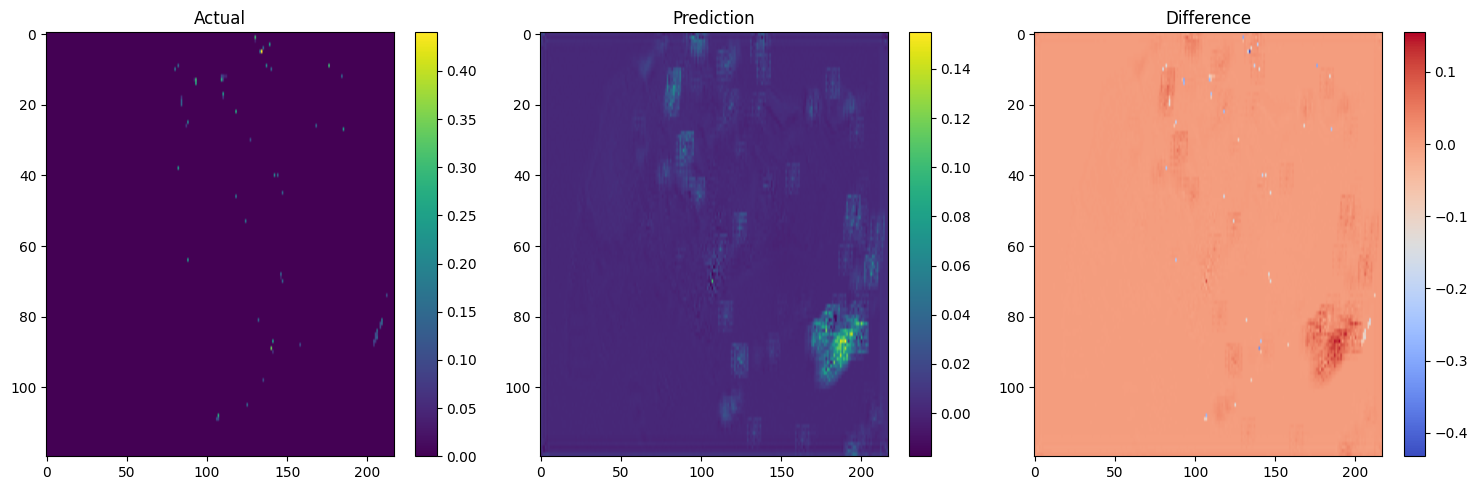

In [ ]:
import matplotlib.pyplot as plt
import torch

model2.eval()

# get one batch
inputs, labels = next(iter(train_loader),4)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model2(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

print(f"Prediction range: {pred.min():.4f} to {pred.max():.4f}")
print(f"Actual range: {actual.min():.4f} to {actual.max():.4f}")
print(f"Difference range: {diff.min():.4f} to {diff.max():.4f}")

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto', cmap='viridis')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto', cmap='viridis')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto', cmap='coolwarm')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

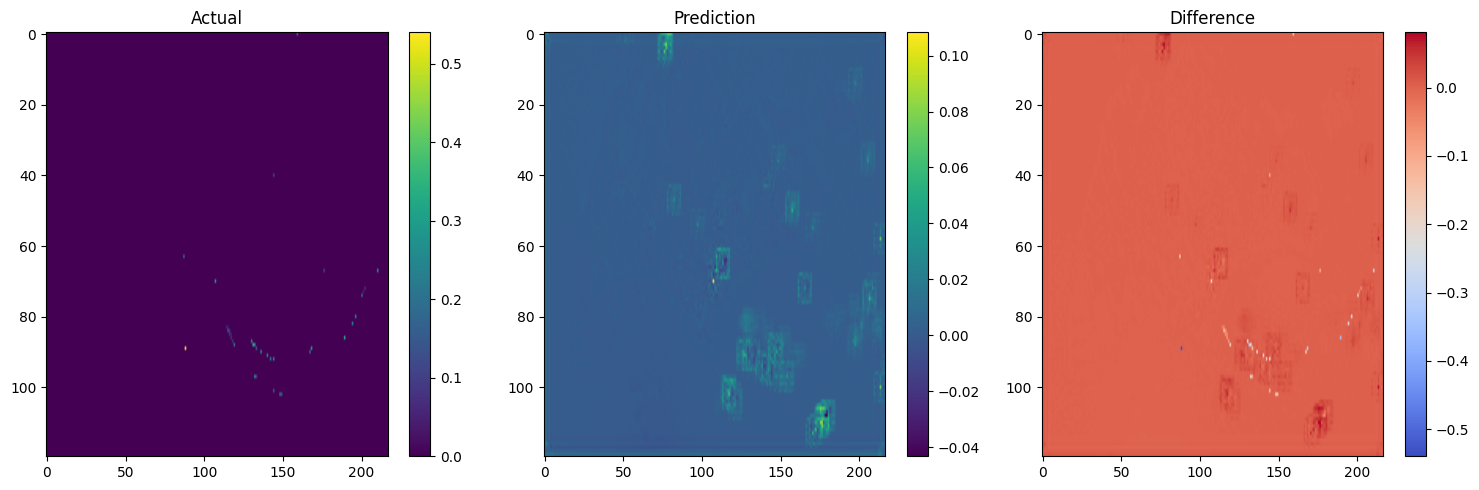

In [ ]:
import matplotlib.pyplot as plt
import torch

model2.eval()

# get one batch
inputs, labels = next(iter(test_loader),3)
inputs = inputs.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model2(inputs)
sample_no=6
# pick one sample from the batch
pred = outputs[sample_no]
actual = labels[sample_no]

# if shape is [1, H, W], remove the channel dimension
if pred.dim() == 3:
    pred = pred.squeeze(0)

if actual.dim() == 3:
    actual = actual.squeeze(0)

# move to cpu and convert to numpy
pred = pred.cpu().numpy()
actual = actual.cpu().numpy()

diff = pred - actual

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(actual, aspect='auto', cmap='viridis')
plt.title("Actual")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(pred, aspect='auto', cmap='viridis')
plt.title("Prediction")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff, aspect='auto', cmap='coolwarm')
plt.title("Difference")
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
sample_idx = 100

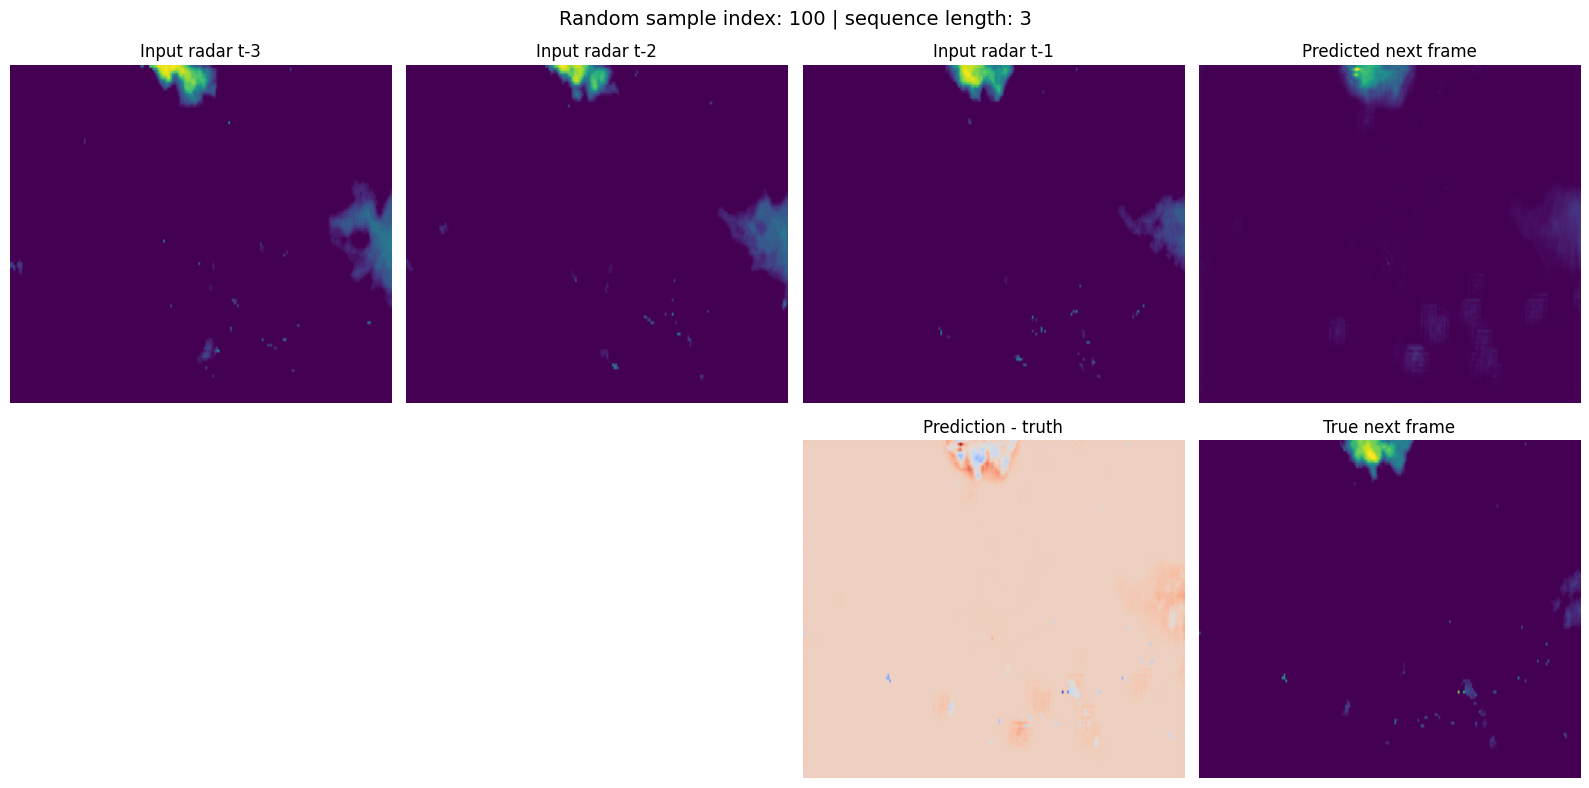

In [ ]:
import matplotlib.pyplot as plt

model2.eval()

#sample_idx = 5
sample_inputs, sample_target = test_dataset[sample_idx] if len(test_dataset) > 0 else dataset[sample_idx]

with torch.no_grad():
    sample_batch = sample_inputs.unsqueeze(0).to(device)
    sample_outputs = model2(sample_batch)
    sample_prediction = sample_outputs[0].clamp_min(0).cpu()

sample_inputs = sample_inputs.cpu()
sample_target = sample_target.cpu()

num_steps = sample_inputs.shape[0]
fig, axes = plt.subplots(2, max(num_steps + 1, 3), figsize=(4 * max(num_steps + 1, 3), 8))
axes = axes.reshape(2, -1)

for step in range(axes.shape[1]):
    axes[0, step].axis('off')
    axes[1, step].axis('off')

for step in range(num_steps):
    input_frame = sample_inputs[step]
    # Multimodal input has 5 channels (radar + env). Visualize radar channel only.
    if input_frame.dim() == 3:
        input_frame = input_frame[0]
    axes[0, step].imshow(input_frame.numpy(), aspect='auto', cmap='viridis')
    axes[0, step].set_title(f'Input radar t-{num_steps - step}')
    axes[0, step].axis('off')

pred_frame = sample_prediction
if pred_frame.dim() == 3:
    pred_frame = pred_frame.squeeze(0)
axes[0, num_steps].imshow(pred_frame.numpy(), aspect='auto', cmap='viridis')
axes[0, num_steps].set_title('Predicted next frame')
axes[0, num_steps].axis('off')

target_frame = sample_target
if target_frame.dim() == 3:
    target_frame = target_frame.squeeze(0)
diff_frame = pred_frame.numpy() - target_frame.numpy()
axes[1, num_steps - 1].imshow(diff_frame, aspect='auto', cmap='coolwarm')
axes[1, num_steps - 1].set_title('Prediction - truth')
axes[1, num_steps - 1].axis('off')

axes[1, num_steps].imshow(target_frame.numpy(), aspect='auto', cmap='viridis')
axes[1, num_steps].set_title('True next frame')
axes[1, num_steps].axis('off')

fig.suptitle(f'Random sample index: {sample_idx} | sequence length: {num_steps}', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
from datetime import datetime

save_dir = Path(r"C:\Users\Jacobs laptop\rainraingoaway\models")
save_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = save_dir / f"model_best_{timestamp}.pkl"
torch.save(model2.state_dict(), model_path)
print(f"saved to {model_path}")

saved to C:\Users\Jacobs laptop\rainraingoaway\models\model_best_20260828_160201.pkl


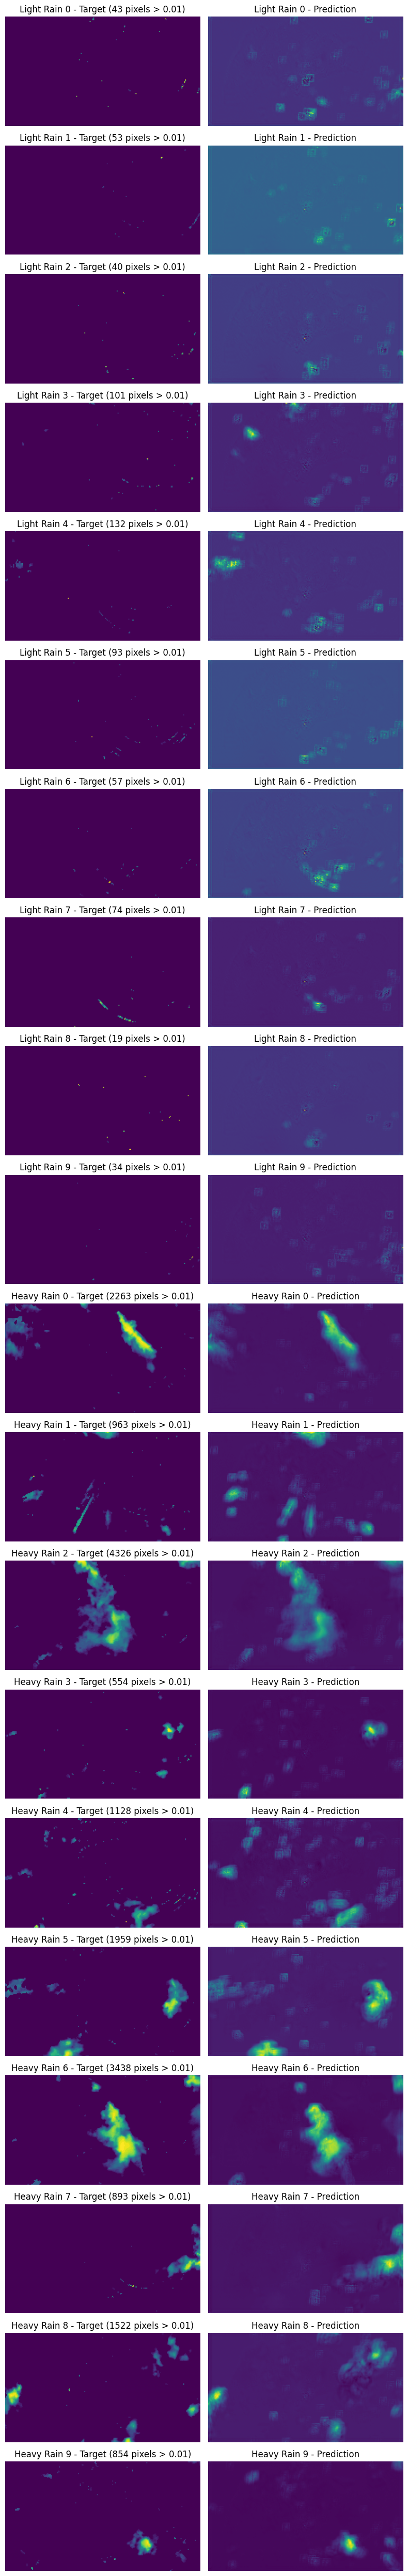

In [ ]:
model.eval()
with torch.no_grad():
    all_samples = []
    pixel_threshold = 0.01  # Pixels > 0.01 are considered rain
    
    # Collect all samples first
    for batch_inputs, batch_targets in test_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        
        batch_outputs = model(batch_inputs).squeeze(1)  # [batch, H, W]
        
        for i in range(batch_outputs.shape[0]):
            pred = batch_outputs[i].cpu().numpy()
            targ = batch_targets[i].cpu().numpy()
            
            rain_pixel_count = np.count_nonzero(targ > pixel_threshold)
            all_samples.append((pred, targ, rain_pixel_count))
    
    # Randomize the order
    np.random.seed(42)
    np.random.shuffle(all_samples)
    
    # Separate into light and heavy rain
    pixel_count_threshold = 500
    light_rain_samples = []
    heavy_rain_samples = []
    
    for pred, targ, count in all_samples:
        if count > pixel_count_threshold:
            if len(heavy_rain_samples) < 10:
                heavy_rain_samples.append((pred, targ, count))
        else:
            if len(light_rain_samples) < 10:
                light_rain_samples.append((pred, targ, count))
        
        if len(light_rain_samples) >= 10 and len(heavy_rain_samples) >= 10:
            break
    
    # Create grid: top 10 rows = light rain, bottom 10 rows = heavy rain
    fig, axes = plt.subplots(20, 2, figsize=(8, 50))
    
    # Light rain samples (first 10 rows)
    for idx, (pred, targ, count) in enumerate(light_rain_samples):
        axes[idx, 0].imshow(targ, aspect='auto', cmap='viridis')
        axes[idx, 0].set_title(f'Light Rain {idx} - Target ({count} pixels > {pixel_threshold})')
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(pred, aspect='auto', cmap='viridis')
        axes[idx, 1].set_title(f'Light Rain {idx} - Prediction')
        axes[idx, 1].axis('off')
    
    # Heavy rain samples (next 10 rows)
    for idx, (pred, targ, count) in enumerate(heavy_rain_samples):
        row = 10 + idx
        axes[row, 0].imshow(targ, aspect='auto', cmap='viridis')
        axes[row, 0].set_title(f'Heavy Rain {idx} - Target ({count} pixels > {pixel_threshold})')
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(pred, aspect='auto', cmap='viridis')
        axes[row, 1].set_title(f'Heavy Rain {idx} - Prediction')
        axes[row, 1].axis('off')
    
    plt.tight_layout()
    plt.show()

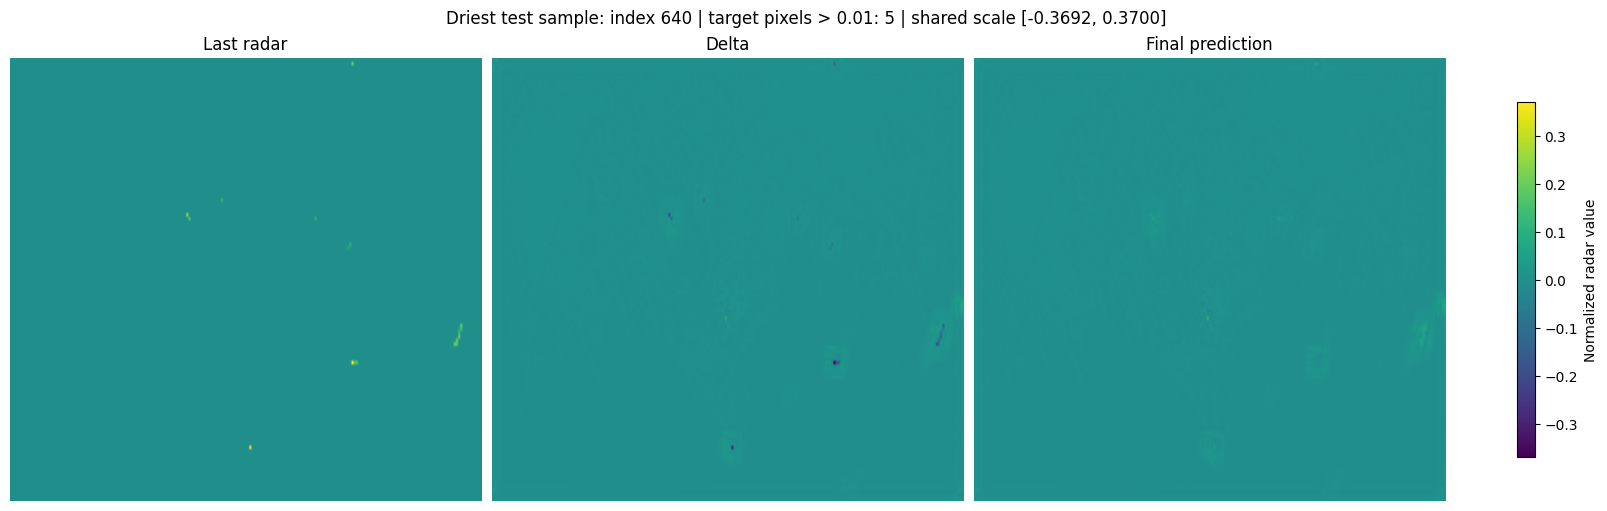

Selected test index: 640
Target rain pixels > 0.01: 5
Last radar range: 0.000000 to 0.370000
Delta range: -0.369225 to 0.097546
Final prediction range: -0.023464 to 0.097546
Max reconstruction error (prediction - last_radar - delta): 0.00000000


In [ ]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import torch

# Reload the class so this cell uses the diagnostic-capable forward method.
import models.multi_modal_convlstm as multimodal_model_module
importlib.reload(multimodal_model_module)
ConvLSTM_MM = multimodal_model_module.ConvLSTM_MM

# Recreate the evaluation model with the checkpoint already used above.
diagnostic_model = ConvLSTM_MM(
    input_dim=7,
    hidden_dim=[32, 64],
    kernel_size=[(3, 3), (3, 3)],
    num_layers=2,
    batch_first=True,
    bias=True,
    land_use_channels=33,
    land_use_feature_dim=8,
).to(device)
diagnostic_model.load_state_dict(torch.load(
    r"C:\Users\Jacobs laptop\rainraingoaway\src\model_best.pkl",
    map_location=device,
))
diagnostic_model.eval()

# Select the driest test example, preferring a genuinely nearly dry target.
dry_threshold = 0.01
dry_candidates = []
for test_index in range(len(test_dataset)):
    _, target = test_dataset[test_index]
    target_array = target.detach().cpu().numpy()
    rain_pixel_count = np.count_nonzero(target_array > dry_threshold)
    dry_candidates.append((rain_pixel_count, test_index))

rain_pixel_count, dry_index = min(dry_candidates)
diagnostic_input, diagnostic_target = test_dataset[dry_index]

with torch.no_grad():
    diagnostic_prediction, last_radar, delta = diagnostic_model(
        diagnostic_input.unsqueeze(0).to(device),
        return_components=True,
    )

last_radar = last_radar[0, 0].cpu().numpy()
delta = delta[0, 0].cpu().numpy()
prediction = diagnostic_prediction[0, 0].cpu().numpy()

# Use one scale for all three images so their values are directly comparable.
plot_values = np.concatenate((last_radar.ravel(), delta.ravel(), prediction.ravel()))
vmin, vmax = plot_values.min(), plot_values.max()
if np.isclose(vmin, vmax):
    vmax = vmin + 1e-6

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
images = [last_radar, delta, prediction]
titles = ["Last radar", "Delta", "Final prediction"]
for axis, image, title in zip(axes, images, titles):
    image_plot = axis.imshow(image, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.axis("off")

fig.colorbar(image_plot, ax=axes, shrink=0.8, label="Normalized radar value")
fig.suptitle(
    f"Driest test sample: index {dry_index} | "
    f"target pixels > {dry_threshold}: {rain_pixel_count} | "
    f"shared scale [{vmin:.4f}, {vmax:.4f}]"
)
plt.show()

print(f"Selected test index: {dry_index}")
print(f"Target rain pixels > {dry_threshold}: {rain_pixel_count}")
print(f"Last radar range: {last_radar.min():.6f} to {last_radar.max():.6f}")
print(f"Delta range: {delta.min():.6f} to {delta.max():.6f}")
print(f"Final prediction range: {prediction.min():.6f} to {prediction.max():.6f}")
print(f"Max reconstruction error (prediction - last_radar - delta): "
      f"{np.max(np.abs(prediction - last_radar - delta)):.8f}")

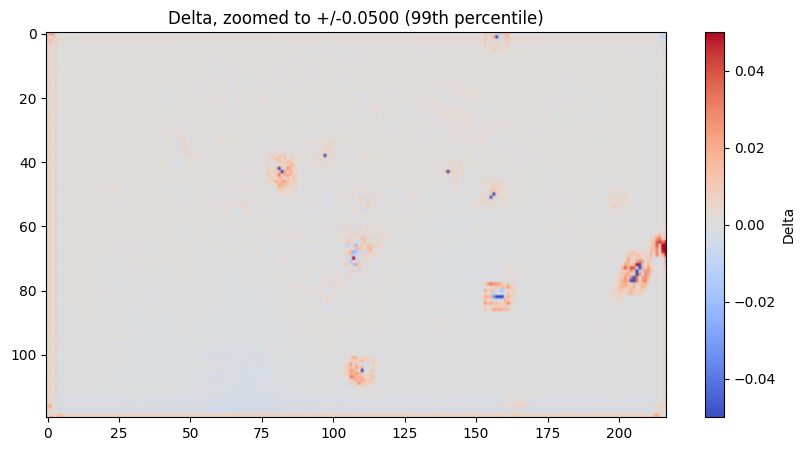

Delta zoom limit: +/-0.050000


In [ ]:
# Replot the residual alone with a robust, symmetric scale.
limit = np.quantile(np.abs(delta), 0.99)
limit = max(float(limit), 0.05)

plt.figure(figsize=(10, 5))
plt.imshow(
    delta,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
    aspect="auto",
)
plt.colorbar(label="Delta")
plt.title(f"Delta, zoomed to +/-{limit:.4f} (99th percentile)")
plt.show()

print(f"Delta zoom limit: +/-{limit:.6f}")

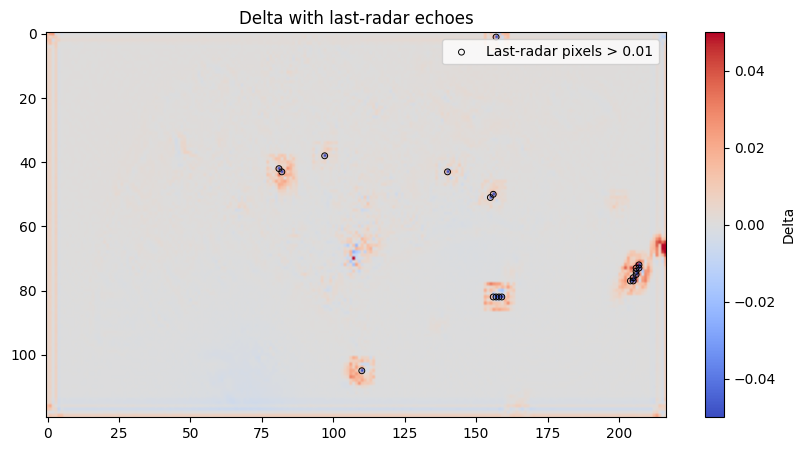

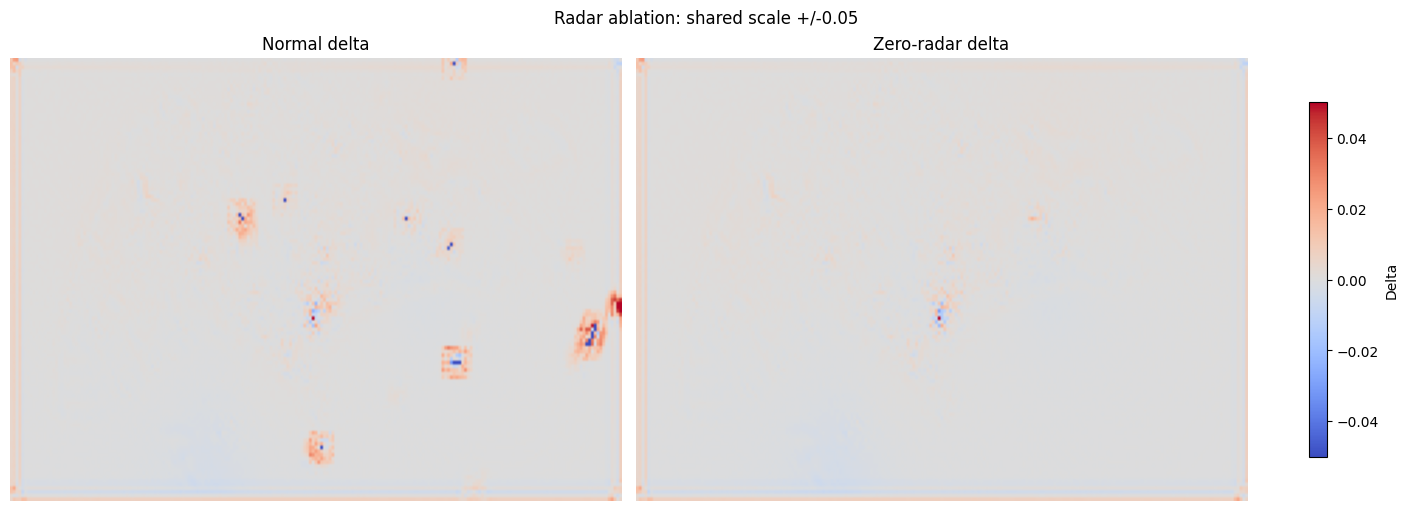

Dry pixels where delta > 0.01: normal=1.0947%, zero-radar=0.1383%
Dry pixels where delta > 0.02: normal=0.2996%, zero-radar=0.0192%
Last-radar pixels > 0.01: 20
Normal delta range: -0.369225 to 0.097546
Zero-radar delta range: -0.029532 to 0.081998
Mean absolute delta change after radar ablation: 0.000506
Max absolute delta change after radar ablation: 0.368941


In [ ]:
# Test whether the residual boxes are centered on sparse radar echoes.
limit = 0.05
rain_threshold = 0.01

rain_y, rain_x = np.where(last_radar > rain_threshold)

fig, axis = plt.subplots(figsize=(10, 5))
delta_plot = axis.imshow(
    delta,
    cmap="coolwarm",
    vmin=-limit,
    vmax=limit,
    aspect="auto",
)
axis.scatter(
    rain_x,
    rain_y,
    s=18,
    facecolors="none",
    edgecolors="black",
    linewidths=0.7,
    label=f"Last-radar pixels > {rain_threshold}",
)
axis.set_title("Delta with last-radar echoes")
axis.legend(loc="upper right")
plt.colorbar(delta_plot, ax=axis, label="Delta")
plt.show()

# Keep every channel except radar unchanged, then run the same sample again.
x_zero_radar = diagnostic_input.clone()
x_zero_radar[:, 0] = 0

with torch.no_grad():
    prediction_zero, _, delta_zero = diagnostic_model(
        x_zero_radar.unsqueeze(0).to(device),
        return_components=True,
    )

delta_zero = delta_zero[0, 0].cpu().numpy()
prediction_zero = prediction_zero[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, image, title in zip(
    axes,
    [delta, delta_zero],
    ["Normal delta", "Zero-radar delta"],
):
    image_plot = axis.imshow(
        image,
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        aspect="auto",
    )
    axis.set_title(title)
    axis.axis("off")
fig.colorbar(image_plot, ax=axes, shrink=0.8, label="Delta")
fig.suptitle("Radar ablation: shared scale +/-0.05")
plt.show()

# Quantify false-rain residuals on pixels that are dry in the target.
dry_pixels = diagnostic_target.detach().cpu().numpy() <= rain_threshold
for threshold in (0.01, 0.02):
    normal_rate = np.mean(delta[dry_pixels] > threshold)
    zero_radar_rate = np.mean(delta_zero[dry_pixels] > threshold)
    print(
        f"Dry pixels where delta > {threshold:.2f}: "
        f"normal={normal_rate:.4%}, zero-radar={zero_radar_rate:.4%}"
    )

print(f"Last-radar pixels > {rain_threshold}: {len(rain_x)}")
print(f"Normal delta range: {delta.min():.6f} to {delta.max():.6f}")
print(f"Zero-radar delta range: {delta_zero.min():.6f} to {delta_zero.max():.6f}")
print(
    f"Mean absolute delta change after radar ablation: "
    f"{np.mean(np.abs(delta - delta_zero)):.6f}"
)
print(
    f"Max absolute delta change after radar ablation: "
    f"{np.max(np.abs(delta - delta_zero)):.6f}"
)